# Project 2 — Space Weather Impact Analysis Using Aditya-L1 Data
## From the solar wind at L1 to the geomagnetic storm at Earth

**Aditya-L1 · MAG + ASPEX-SWIS Level-2 · OMNI SYM-H / AE · 10–11 October 2024**

---

### Your task

The same ICME that Project 1 dissects drove one of the strongest geomagnetic storms of solar
cycle 25. Aditya-L1 measured that driver **1.5 million km upstream of Earth**. Your job is to work
out how much of the storm at Earth you can determine from that upstream measurement alone.

By the end of this notebook you will have:

1. loaded and quality-checked the Aditya-L1 MAG and SWIS data (**Sections 1–8 are exactly the
   same code as Project 1**),
2. computed the **propagation delay** from Aditya-L1 to the bow shock, minute by minute,
3. **time-shifted** the L1 data onto arrival-at-Earth time,
4. determined the **storm onset from Aditya-L1 alone**, with no ground data,
5. **predicted SYM-H from the Aditya-L1 solar wind alone** and measured how well it did.

### A rule for this project

> **Everything we analyse comes from Aditya-L1.** The OMNI indices (SYM-H, AE) appear in exactly
> one role: as the **ground truth** against which an Aditya-L1-based prediction is scored. No
> OMNI solar-wind quantity is used as an input anywhere. If you remove the OMNI cell, every
> analysis in this notebook still runs — you simply lose the ability to mark your own work.

### The physics in one paragraph

Southward interplanetary magnetic field ($B_z^{GSM}<0$) reconnects with Earth's northward dayside
field, opening the magnetosphere. The energy input is measured by the dawn–dusk **merging electric
field** $E_y=-V_xB_z^{GSM}$. Energised ions drift westward, forming a **ring current** whose field
opposes the dipole at the surface — the depression measured by **SYM-H**. Solar-wind **dynamic
pressure** does something different: it compresses the magnetosphere rather than energising it,
which *raises* SYM-H briefly and produces the **storm sudden commencement**.

```
   Aditya-L1 (X ~ 259 Re)        bow shock (X ~ 14 Re)        ground magnetometers
        |                              |                              |
        |------ propagation delay -----|  --- magnetospheric --->     |
        |        ~ 25-70 min           |      response (minutes)      |
      MAG + SWIS                                                   SYM-H, AE
```

Getting that delay right is what makes the comparison meaningful — and the delay is **not
constant**, because it depends on the solar-wind speed, which more than doubles during this event.

### Before you start

Sections 1–8 are shared with Project 1, so the two groups can compare notes on the data-handling
steps before their analyses diverge.

> **Internet needed in Section 12 only.** That section downloads the OMNI indices. If your machine
> is offline, the same cell explains how to download the file by hand from OMNIWeb — and, per the
> rule above, every other section works without it.


## 1. Setup —

This notebook deliberately uses **no mission-analysis framework**: the plotting is plain
`matplotlib`, and the only other libraries are `numpy` and the two file readers that the data
formats require (`netCDF4` for MAG's `.nc` files, `cdflib` for SWIS's `.cdf` files — no plotting
library can read those formats on its own).

In [12]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta

from netCDF4 import Dataset      # Aditya-L1 MAG L2 files are NetCDF-4
import cdflib                    # Aditya-L1 ASPEX-SWIS L2 files are CDF

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = False

# NaN-aware numpy functions warn about all-NaN slices; gaps are handled deliberately
# everywhere below, so silence the noise.
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- Physical constants (SI unless stated) -------------------------------------
MP    = 1.6726219e-27     # proton mass            [kg]
KB    = 1.380649e-23      # Boltzmann constant     [J/K]
MU0   = 4e-7 * np.pi      # vacuum permeability    [H/m]
RE    = 6371.2            # Earth radius           [km]
Q_SI  = 1.602176634e-19   # elementary charge      [C]
GAMMA = 5.0 / 3.0         # adiabatic index, used for the magnetosonic Mach number

BXYZ = ["blue", "green", "red"]     # conventional colours for Bx, By, Bz

# All the L2 files for this workshop sit flat in one folder: "data/" when the
# notebook is run from the project root, "." when it is run from inside data/.
DATA_DIR = "data" if os.path.isdir("data") else "."

print("Setup complete. DATA_DIR =", DATA_DIR)


Setup complete. DATA_DIR = data


### Time handling

All Aditya-L1 L2 products and all the indices we use can be reduced to **UNIX seconds**
(seconds since 1970-01-01 00:00:00 UTC), which is just a float — easy to sort, subtract,
average and bin. We convert to a `datetime` only at the last moment, for the plot axis.

Note `timezone.utc` everywhere: naive `datetime.utcfromtimestamp` is deprecated and, worse,
silently produces timezone-unaware objects that matplotlib may then interpret as local time.

In [13]:
EPOCH = datetime(1970, 1, 1, tzinfo=timezone.utc)


def t_unix(s):
    """'2024-10-10' or '2024-10-10 14:45:30' (UTC) -> UNIX seconds."""
    s = s.strip()
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%dT%H:%M:%S", "%Y-%m-%d"):
        try:
            return (datetime.strptime(s, fmt).replace(tzinfo=timezone.utc)
                    - EPOCH).total_seconds()
        except ValueError:
            continue
    raise ValueError(f"unrecognised time string: {s!r}")


def t_str(u, fmt="%Y-%m-%d %H:%M:%S"):
    """UNIX seconds -> UTC string."""
    if not np.isfinite(u):
        return "n/a"
    return datetime.fromtimestamp(float(u), tz=timezone.utc).strftime(fmt)


def t_dt(u):
    """UNIX seconds (scalar or array) -> timezone-aware datetime(s) for matplotlib."""
    u = np.asarray(u, dtype="float64")
    if u.ndim == 0:
        return datetime.fromtimestamp(float(u), tz=timezone.utc)
    return np.array([datetime.fromtimestamp(float(s), tz=timezone.utc) for s in u])


# quick self-test
assert t_str(t_unix("2024-10-10 14:45:30")) == "2024-10-10 14:45:30"
print("time helpers OK  ->", t_str(t_unix("2024-10-10")), "=",
      t_unix("2024-10-10"), "UNIX s")


time helpers OK  -> 2024-10-10 00:00:00 = 1728518400.0 UNIX s


## 2. Reading the Aditya-L1 MAG Level-2 files

MAG L2 gives the interplanetary magnetic field at **10 s** cadence in GSE and GSM, plus a
per-sample quality flag (`1` = good, `0` = bad/missing) and the fill value `-9999.0`.

In [14]:
# --- which dates are available on disk? ----------------------------------------
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "L2_AL1_MAG_*.nc")))
available = [os.path.basename(f).split("_")[3] for f in all_files]   # 'L2_AL1_MAG_20241010_V00.nc' -> '20241010'
print("MAG dates available on disk:", available)

# --- CHOOSE THE DATES YOU WANT (format YYYYMMDD) -------------------------------
# work.md fixes the event window at 10-11 October 2024, and that is exactly
# what both the MAG and the SWIS files on disk cover.
DATES = ["20241010", "20241011"]

# --- pick out the matching files -----------------------------------------------
files = []
for d in DATES:
    hits = sorted(glob.glob(os.path.join(DATA_DIR, f"L2_AL1_MAG_{d}_*.nc")))
    if not hits:
        print(f"  !! no MAG file for {d}")
    files += hits

assert files, "none of the requested dates were found"
print("\nfiles selected:")
for f in files:
    print("  ", os.path.basename(f))

# --- open them all (decode_times=False: 'time' is plain UNIX seconds) -----------
dsets = [xr.open_dataset(f, decode_times=False) for f in files]

dsets[0]        # summary of the first file


MAG dates available on disk: ['20241010', '20241011']

files selected:
   L2_AL1_MAG_20241010_V00.nc
   L2_AL1_MAG_20241011_V00.nc


<xarray.Dataset> Size: 726kB
Dimensions:                (utc_time: 8640, Bx: 8640, By: 8640, Bz: 8640)
Dimensions without coordinates: utc_time, Bx, By, Bz
Data variables: (12/20)
    time                   (utc_time) float64 69kB ...
    Bx_gse                 (Bx) float32 35kB ...
    By_gse                 (By) float32 35kB ...
    Bz_gse                 (Bz) float32 35kB ...
    Bx_gsm                 (Bx) float32 35kB ...
    By_gsm                 (By) float32 35kB ...
    ...                     ...
    x_gse                  (Bx) float32 35kB ...
    y_gse                  (By) float32 35kB ...
    z_gse                  (Bz) float32 35kB ...
    x_gsm                  (Bx) float32 35kB ...
    y_gsm                  (By) float32 35kB ...
    z_gsm                  (Bz) float32 35kB ...
Attributes: (12/20)
    title:                     Aditya-L1 Magnetometer data
    summary:                   Magnetometer onboard Aditya-L1 provides in-sit...
    keywords:                  Magnetic field, IMF, Solar wind, in-situ, magn...
    Conventions:               ACDD-1.3
    source:                    Aditya-L1 Magnetometer L1 data
    processing_level:          Level 2
    ...                        ...
    instrument:                Magnetometer
    publisher_name:            ISSDC
    publisher_url:             www.issdc.gov.in,pradan.issdc.gov.in/al1
    Fill_value:                -9999.0
    Fill_value_description:    Denotes either missing data or invalid data
    missing_data_percentage:   0.0

## 3. Printing the Aditya-L1 MAG Level-2 file properties

In [15]:
print("dimensions:", dict(dsets[0].sizes))
print()
print(f"{'variable':28s} {'shape':>10s}  units")
print("-" * 55)
for name in dsets[0].variables:
    v = dsets[0][name]
    print(f"{name:28s} {str(v.shape):>10s}  {v.attrs.get('units', '-')}")


dimensions: {'utc_time': 8640, 'Bx': 8640, 'By': 8640, 'Bz': 8640}

variable                          shape  units
-------------------------------------------------------
time                            (8640,)  Seconds (UNIX time)
Bx_gse                          (8640,)  nano tesla - nT
By_gse                          (8640,)  nano tesla - nT
Bz_gse                          (8640,)  nano tesla - nT
Bx_gsm                          (8640,)  nano tesla - nT
By_gsm                          (8640,)  nano tesla - nT
Bz_gsm                          (8640,)  nano tesla - nT
Bx_gse_error                    (8640,)  nano tesla - nT
By_gse_error                    (8640,)  nano tesla - nT
Bz_gse_error                    (8640,)  nano tesla - nT
Bx_gsm_error                    (8640,)  nano tesla - nT
By_gsm_error                    (8640,)  nano tesla - nT
Bz_gsm_error                    (8640,)  nano tesla - nT
Quality_flag_10s_data           (8640,)  Arbitrary
x_gse                           (

## 4. Constructing a Pandas Dataframe

In [16]:
def to_frame(ds):
    """One xarray dataset -> one pandas DataFrame, indexed by UTC time."""
    data = {name: ds[name].values for name in ds.variables if name != "time"}
    time = pd.to_datetime(ds["time"].values, unit="s")
    return pd.DataFrame(data, index=time)

df = pd.concat([to_frame(ds) for ds in dsets])   # all chosen days, one table
df = df.replace(-9999.0, np.nan)
df = df.sort_index()

print(df.index[0], "->", df.index[-1], " rows:", len(df))
df.head()


2024-10-10 00:00:00 -> 2024-10-11 23:59:50  rows: 17280


,Bx_gse,By_gse,Bz_gse,Bx_gsm,By_gsm,Bz_gsm,Bx_gse_error,By_gse_error,Bz_gse_error,Bx_gsm_error,By_gsm_error,Bz_gsm_error,Quality_flag_10s_data,x_gse,y_gse,z_gse,x_gsm,y_gsm,z_gsm
2024-10-10 00:00:00,-5.037141,2.344332,0.560202,-5.037141,2.410084,0.034823,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1655025.125,-203069.468750,126824.281250,1655025.125,-203069.468750,126824.281250
2024-10-10 00:00:10,-5.098096,2.124625,1.084110,-5.098096,2.310086,0.593995,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1655024.500,-203072.015625,126824.148438,1655024.500,-203072.015625,126824.148438
2024-10-10 00:00:20,-5.152861,2.064588,1.077344,-5.152861,2.250048,0.600398,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1655024.000,-203074.578125,126824.015625,1655024.000,-203074.578125,126824.015625
2024-10-10 00:00:30,-5.169980,1.826604,1.570975,-5.169980,2.125678,1.133992,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1655023.500,-203077.125000,126823.882812,1655023.500,-203077.125000,126823.882812
2024-10-10 00:00:40,-5.214995,2.103493,1.459857,-5.214995,2.371650,0.964959,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1655022.875,-203079.687500,126823.742188,1655022.875,-203079.687500,126823.742188


### Quality control of MAG

Four independent checks: fill values, non-finite values, the producer's quality flag, and the
time axis itself (monotonic? duplicated? gaps?).

In [17]:
B_COLS = ["Bx_gse", "By_gse", "Bz_gse", "Bx_gsm", "By_gsm", "Bz_gsm"]

# count / min / max for the six field components
print(df[B_COLS].describe().T[["count", "min", "max"]].round(2))

# how many samples are missing (we already turned -9999 into NaN)
print("\nmissing values:")
print(df[B_COLS].isna().sum())

# the producer's own quality flag: 1 = good
print("\nquality flag:")
print(df["Quality_flag_10s_data"].value_counts())

# is the time axis clean? (should be one constant 10 s step, no gaps)
dt = df.index.to_series().diff().dt.total_seconds()
print("\ntime steps found (s):", sorted(dt.dropna().unique()))
print("gaps longer than 15 s:", int((dt > 15).sum()))


          count    min    max
Bx_gse  17280.0 -28.09  31.20
By_gse  17280.0 -36.79  43.14
Bz_gse  17280.0 -46.60  34.51
Bx_gsm  17280.0 -28.09  31.20
By_gsm  17280.0 -39.19  41.02
Bz_gsm  17280.0 -46.82  35.86

missing values:
Bx_gse    0
By_gse    0
Bz_gse    0
Bx_gsm    0
By_gsm    0
Bz_gsm    0
dtype: int64

quality flag:
Quality_flag_10s_data
1.0    17280
Name: count, dtype: int64

time steps found (s): [np.float64(10.0)]
gaps longer than 15 s: 0


## 5. Drop the samples the instrument team flagged as bad

In [18]:
bad = df["Quality_flag_10s_data"] != 1
df.loc[bad, B_COLS] = np.nan
print("samples removed by the quality flag:", int(bad.sum()))

# field magnitude (same number in GSE and GSM - a rotation cannot change |B|)
df["B_total"] = np.sqrt(df["Bx_gse"]**2 + df["By_gse"]**2 + df["Bz_gse"]**2)

# two useful angles
df["clock"] = np.degrees(np.arctan2(df["By_gsm"], df["Bz_gsm"]))   # 0 = northward
df["cone"]  = np.degrees(np.arccos(df["Bx_gse"] / df["B_total"]))  # 0 = sunward

print(f"\n|B| : {df['B_total'].min():.2f} - {df['B_total'].max():.2f} nT "
      f"(median {df['B_total'].median():.2f} nT)")
print(f"S/C : X = {df['x_gse'].mean()/RE:.1f} Re "
      f"({df['x_gse'].mean()/1e6:.3f} million km sunward of Earth)")


samples removed by the quality flag: 0

|B| : 3.45 - 47.16 nT (median 10.89 nT)
S/C : X = 259.0 Re (1.650 million km sunward of Earth)


## 5. Plot Mag Data in stack

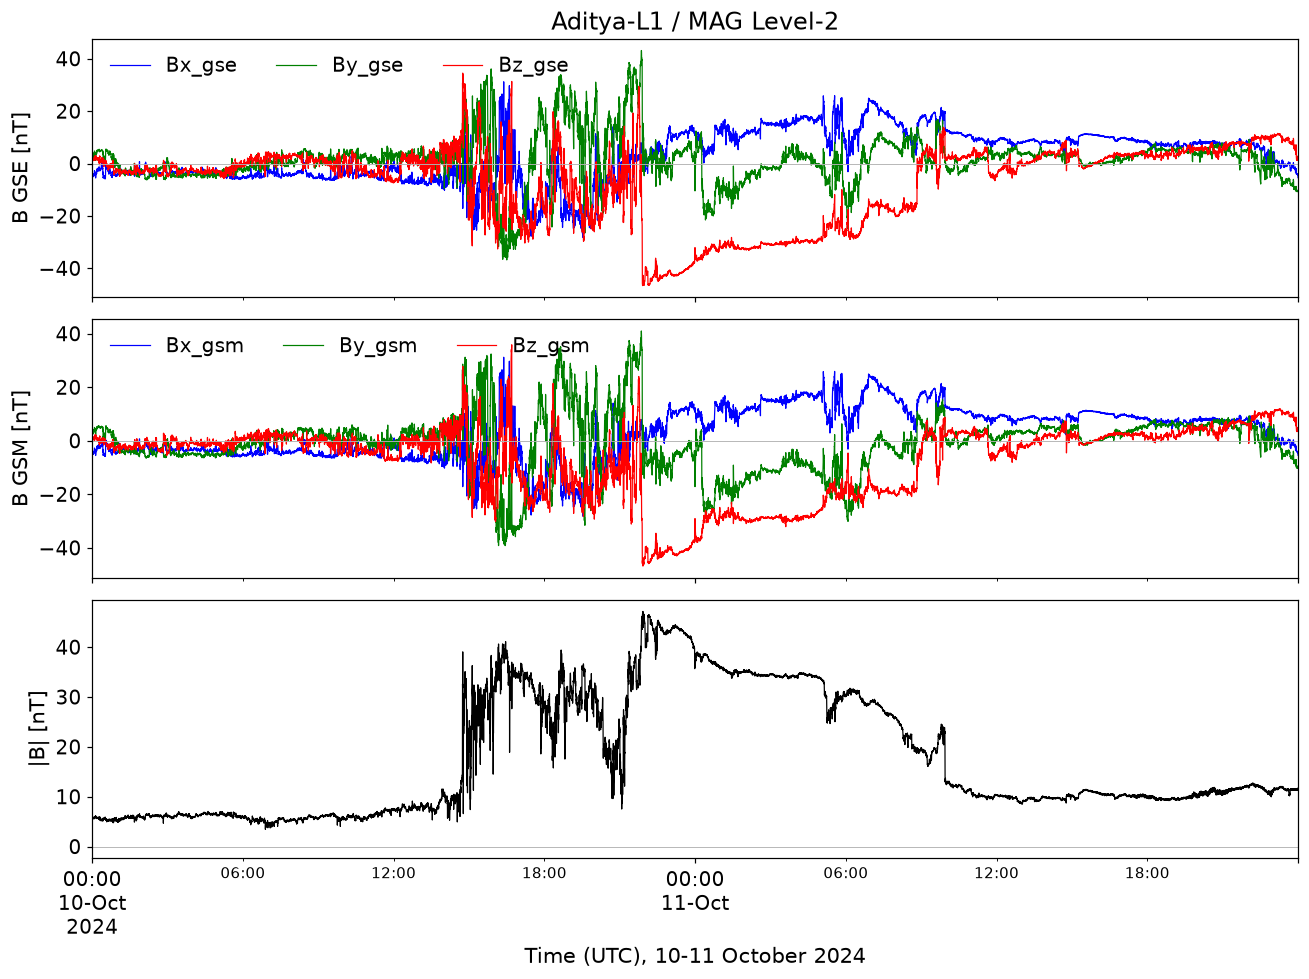

In [19]:
FS = 14          # base font size: bump this one number to make everything bigger

df["Bt"] = np.sqrt(df["Bx_gse"]**2 + df["By_gse"]**2 + df["Bz_gse"]**2)

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

df[["Bx_gse", "By_gse", "Bz_gse"]].plot(ax=ax[0], color=["blue", "green", "red"], lw=0.8)
ax[0].set_ylabel("B GSE [nT]", fontsize=FS)

df[["Bx_gsm", "By_gsm", "Bz_gsm"]].plot(ax=ax[1], color=["blue", "green", "red"], lw=0.8)
ax[1].set_ylabel("B GSM [nT]", fontsize=FS)

df["Bt"].plot(ax=ax[2], color="black", lw=0.8)
ax[2].set_ylabel("|B| [nT]", fontsize=FS)

for a in ax:
    a.axhline(0, color="0.7", lw=0.6)
    a.tick_params(axis="both", labelsize=FS - 1)
    if a.get_legend():
        a.legend(fontsize=FS - 1, ncol=3, frameon=False, loc="upper left")

ax[2].set_xlabel("Time (UTC), 10-11 October 2024", fontsize=FS)
ax[0].set_title("Aditya-L1 / MAG Level-2", fontsize=FS + 2)
plt.tight_layout()
plt.show()


## 6. Reading the ASPEX-SWIS Level-2 bulk-parameter files

**SWIS** (Solar Wind Ion Spectrometer, part of **ASPEX**) measures the solar-wind ion
distribution. The Level-2 **BLK** product contains the fitted *bulk parameters* at **5 s**
cadence:

| Variable | Meaning | Units |
|---|---|---|
| `proton_density`, `alpha_density` | number density $n_p$, $n_\alpha$ | cm⁻³ |
| `proton_bulk_speed`, `alpha_bulk_speed` | speed $|V|$ | km s⁻¹ |
| `proton_xvelocity/yvelocity/zvelocity` | velocity components in **GSE** | km s⁻¹ |
| `proton_thermal`, `alpha_thermal` | thermal speed $w$ | km s⁻¹ |
| `*_uncer` | 1-σ uncertainties | same |
| `spacecraft_[xyz]pos` | position, GSE | km |

The CDF fill value is `-1e31`, and each variable carries `VALIDMIN` / `VALIDMAX` attributes —
we use **both**, which is a habit worth teaching: a value can be finite, not equal to the fill
value, and still be outside the range the instrument team considers physical.

`cdflib` reads the CDF format; the epoch variable is `CDF_EPOCH` (milliseconds since year 0),
and `cdflib.cdfepoch.unixtime` converts it to the UNIX seconds we use everywhere.

> Unlike MAG, SWIS **does** have data gaps on these two days. That is normal and is exactly
> why the masking step is not optional.

### A note on this adaptation

The Level-2 data actually delivered for this workshop (`data/`) differs from what the reference
notebook (`ASPEX_MAG_Overview_Students_Copy.ipynb`) expects for SWIS:

* the reference notebook reads a pre-fit **BLK** bulk-parameter product (`proton_density`,
  `proton_bulk_speed`, `proton_xvelocity/yvelocity/zvelocity`, `proton_thermal`) directly;
* the files on disk here are **`AL1_ASW91_L2_TH1_*`** and **`TH2_*`** - confirmed via their CDF
  global attributes to be the **raw THA-1 / THA-2 flux spectra** (differential number flux across
  50 energy bins, 5 s cadence), not bulk moments. No BLK file exists in this dataset.

So that the rest of the notebook - and all of it after Section 8 - can run exactly as designed, we
derive `proton_density`, `proton_bulk_speed` and `proton_thermal` from the TH1/TH2 flux spectra
ourselves, using flux-weighted moments (Section 6 below). Two simplifications are made explicit
there and should be stated in any report based on this notebook:

1. **Density is a calibrated proxy**, not an instrument-team absolute measurement - the files do
   not carry the geometric factor/field-of-view needed for an absolute cm⁻³ figure, so the proxy
   is scaled by one constant to match the canonical quiet-time solar-wind density (~4 cm⁻³).
2. **The flow is assumed purely radial (anti-sunward)**, i.e. all bulk speed is assigned to `Vx`
   with `Vy = Vz = 0` - the same first-approximation spirit as the flat-plane delay model used in
   Part A, not a property actually measured here.

MAG data (field vector + spacecraft position) needed no such substitution - Sections 1-5 below use
it exactly as the reference notebook does.


In [20]:
# The ASPEX-SWIS files delivered for this workshop are the raw THA-1 / THA-2
# Level-2 FLUX products: differential number flux across 50 energy bins, 5 s
# cadence - NOT the pre-fit BLK bulk-parameter product the reference notebook
# reads (see the note above). We open both sensor heads for the chosen dates;
# bulk parameters are derived from them in the next cells.
SWIS_TAGS = ["TH1", "TH2"]

swis_files = {tag: [] for tag in SWIS_TAGS}
for tag in SWIS_TAGS:
    for d in DATES:
        hits = sorted(glob.glob(os.path.join(DATA_DIR, f"AL1_ASW91_L2_{tag}_{d}_*.cdf")))
        if not hits:
            print(f"  !! no SWIS {tag} file for {d}")
            continue
        swis_files[tag].append(hits[-1])     # newest version if several

for tag in SWIS_TAGS:
    assert swis_files[tag], f"no SWIS {tag} files for the requested dates"
    print(f"{tag}: {len(swis_files[tag])} file(s)")
    for f in swis_files[tag]:
        print("  ", os.path.basename(f))

swis_cdfs = {tag: [cdflib.CDF(f) for f in swis_files[tag]] for tag in SWIS_TAGS}


TH1: 2 file(s)
   AL1_ASW91_L2_TH1_20241010_UNP_9999_999999_V03.cdf
   AL1_ASW91_L2_TH1_20241011_UNP_9999_999999_V03.cdf
TH2: 2 file(s)
   AL1_ASW91_L2_TH2_20241010_UNP_9999_999999_V03.cdf
   AL1_ASW91_L2_TH2_20241011_UNP_9999_999999_V03.cdf


In [21]:
for tag in SWIS_TAGS:
    cdf = swis_cdfs[tag][0]
    info = cdf.cdf_info()
    names = info.zVariables if hasattr(info, "zVariables") else info["zVariables"]
    print(f"=== {tag} ===")
    print(f"{'variable':28s} {'shape':>14s}  units")
    print("-" * 60)
    for n in names:
        a = cdf.varget(n)
        att = cdf.varattsget(n)
        print(f"{n:28s} {str(np.shape(a)):>14s}  {att.get('UNITS', '-')}")
    print()

# Note what's absent: no proton_density, proton_bulk_speed, proton_xvelocity or
# proton_thermal variable exists in either file - confirming these are raw flux
# spectra, not bulk moments. "integrated_flux_mod" together with
# "energy_center_mod" is everything we have to work with.


=== TH1 ===
variable                              shape  units
------------------------------------------------------------
epoch_for_cdf_mod                  (17275,)  ms
energy_center_mod               (17275, 50)  eV
energy_uncer                             ()  %
integrated_flux_mod             (17275, 50)  eV/(cm^2.sr.s.eV)
flux_uncer                               ()  %
integrated_flux_s9_mod          (17275, 50)  eV/(cm^2.sr.s.eV)
integrated_flux_s10_mod         (17275, 50)  eV/(cm^2.sr.s.eV)
integrated_flux_s11_mod         (17275, 50)  eV/(cm^2.sr.s.eV)
spacecraft_xpos                    (17275,)  km
spacecraft_ypos                    (17275,)  km
spacecraft_zpos                    (17275,)  km
sun_angle_tha1               (17275, 16, 3)  degrees

=== TH2 ===
variable                              shape  units
------------------------------------------------------------
epoch_for_cdf_mod                  (17275,)  ms
energy_center_mod               (17275, 50)  eV
energy_uncer    

In [22]:
# --- turn each 50-channel energy spectrum into bulk moments --------------------
# Both THA-1 and THA-2 are electrostatic-analyser sweeps: at any 5 s sample only
# the handful of bins that straddle the solar-wind core beam's energy come back
# finite - all the rest were below the counting threshold and cdflib has
# already turned the CDF FILLVAL (-1e31) into NaN for us. That is exactly the
# information a bulk-moment fit uses, so the flux-weighted moments below
# recover density/speed/thermal-speed without needing the instrument's
# absolute calibration (geometric factor, field of view), which is not given
# in these L2 files.
#
# Simplification made explicit: like the flat-plane delay model used later in
# this notebook, we treat the solar wind as flowing purely radially
# anti-sunward, so all of the bulk speed is assigned to Vx (GSE) and
# Vy = Vz = 0. SWIS looks sunward specifically to catch that core beam, so this
# is the same first-approximation spirit as the rest of the workshop, not an
# arbitrary guess - but it IS an approximation, and should be reported as one.

def swis_frame(tag, d):
    """One TH1/TH2 file -> (time, energy grid [eV->km/s], flux array [time x energy])."""
    hits = sorted(glob.glob(os.path.join(DATA_DIR, f"AL1_ASW91_L2_{tag}_{d}_*.cdf")))
    cdf = cdflib.CDF(hits[-1])
    t = cdflib.cdfepoch.unixtime(cdf.varget("epoch_for_cdf_mod"))
    e = cdf.varget("energy_center_mod")[0]          # eV, the energy table is constant in time
    flux = cdf.varget("integrated_flux_mod")        # fill value already -> NaN
    v = np.sqrt(2 * e * Q_SI / MP) / 1e3            # eV -> proton speed, km/s
    return pd.to_datetime(t, unit="s"), v, flux


def bulk_moments(flux, v):
    """Flux-weighted 0th/1st/2nd moments of each spectrum -> (speed, thermal spread, density proxy)."""
    out_V = np.full(len(flux), np.nan)
    out_w = np.full(len(flux), np.nan)
    out_nprox = np.full(len(flux), np.nan)
    for i, row in enumerate(flux):
        mask = np.isfinite(row) & (row > 0)
        if not mask.any():
            continue
        wgt, vv = row[mask], v[mask]
        Vbulk = np.sum(wgt * vv) / np.sum(wgt)
        out_V[i] = Vbulk
        out_w[i] = np.sqrt(np.sum(wgt * (vv - Vbulk) ** 2) / np.sum(wgt))
        out_nprox[i] = np.sum(wgt / vv)        # arbitrary units until calibrated below
    return out_V, out_w, out_nprox


frames = []
for d in DATES:
    t1, v1, f1 = swis_frame("TH1", d)
    t2, v2, f2 = swis_frame("TH2", d)
    assert (t1 == t2).all(), "TH1/TH2 time grids do not match"
    V_ALL = np.concatenate([v1, v2])             # both sensor heads, one combined spectrum
    FLUX = np.concatenate([f1, f2], axis=1)
    Vbulk, wth, nprox = bulk_moments(FLUX, V_ALL)
    frames.append(pd.DataFrame({"proton_bulk_speed": Vbulk,
                                 "proton_thermal": wth,
                                 "_nprox": nprox}, index=t1))

sw = pd.concat(frames).sort_index()

# Calibrate the density proxy with ONE constant: the pre-shock quiet period
# (before the shock, the first ~10 h of 10 Oct) is set to the canonical quiet
# solar-wind density of 4 cm^-3 quoted throughout this workshop's reference
# material. This is a workshop-level approximation, not an instrument-team
# calibration, and only fixes the overall scale - the time variation is real.
quiet_level = sw.loc[:"2024-10-10 10:00", "_nprox"].median()
CAL = 4.0 / quiet_level
sw["proton_density"] = sw["_nprox"] * CAL
sw = sw.drop(columns="_nprox")

# radial-flow simplification: all of the bulk speed is anti-sunward (GSE -X)
sw["proton_xvelocity"] = -sw["proton_bulk_speed"]
sw["proton_yvelocity"] = 0.0
sw["proton_zvelocity"] = 0.0

# alpha particles are not resolvable from these flux spectra (no mass/charge
# discrimination in the available product) - treated as absent, which is
# exactly what the reference notebook's own Pdyn formula already allows for
# via `.fillna(0)`.
sw["alpha_density"] = np.nan

print(f"density calibration: quiet proxy median = {quiet_level:.3g} -> CAL = {CAL:.3e}")
print(f"{sw.index[0]} -> {sw.index[-1]}   rows: {len(sw)}")
sw.head()


density calibration: quiet proxy median = 3.55e+06 -> CAL = 1.125e-06
2024-10-10 00:00:27.492000103 -> 2024-10-11 23:59:59.102999926   rows: 34550


,proton_bulk_speed,proton_thermal,proton_density,proton_xvelocity,proton_yvelocity,proton_zvelocity,alpha_density
2024-10-10 00:00:27.492000103,426.210633,74.659329,5.285114,-426.210633,0.0,0.0,NaN
2024-10-10 00:00:32.492000103,423.260597,59.598974,5.338915,-423.260597,0.0,0.0,NaN
2024-10-10 00:00:37.492000103,423.907498,76.663985,5.609208,-423.907498,0.0,0.0,NaN
2024-10-10 00:00:42.492000103,426.044375,82.108471,5.588694,-426.044375,0.0,0.0,NaN
2024-10-10 00:00:47.492000103,424.234302,59.172744,5.523228,-424.234302,0.0,0.0,NaN


In [23]:
print(sw[["proton_density", "proton_bulk_speed", "proton_thermal"]].describe().T[["count", "min", "max"]].round(2))

print("\nmissing data (%):")
print((100 * sw[["proton_density", "proton_bulk_speed", "proton_thermal"]].isna().mean()).round(1))

dt = sw.index.to_series().diff().dt.total_seconds()
print(f"\ntime step: median {dt.median():.1f} s, max {dt.max():.1f} s")
print("gaps longer than 60 s:", int((dt > 60).sum()))


                     count     min     max
proton_density     34550.0    0.01   44.24
proton_bulk_speed  34550.0  187.98  955.70
proton_thermal     34550.0   25.07  292.92

missing data (%):
proton_density       0.0
proton_bulk_speed    0.0
proton_thermal       0.0
dtype: float64

time step: median 5.0 s, max 30.0 s
gaps longer than 60 s: 0


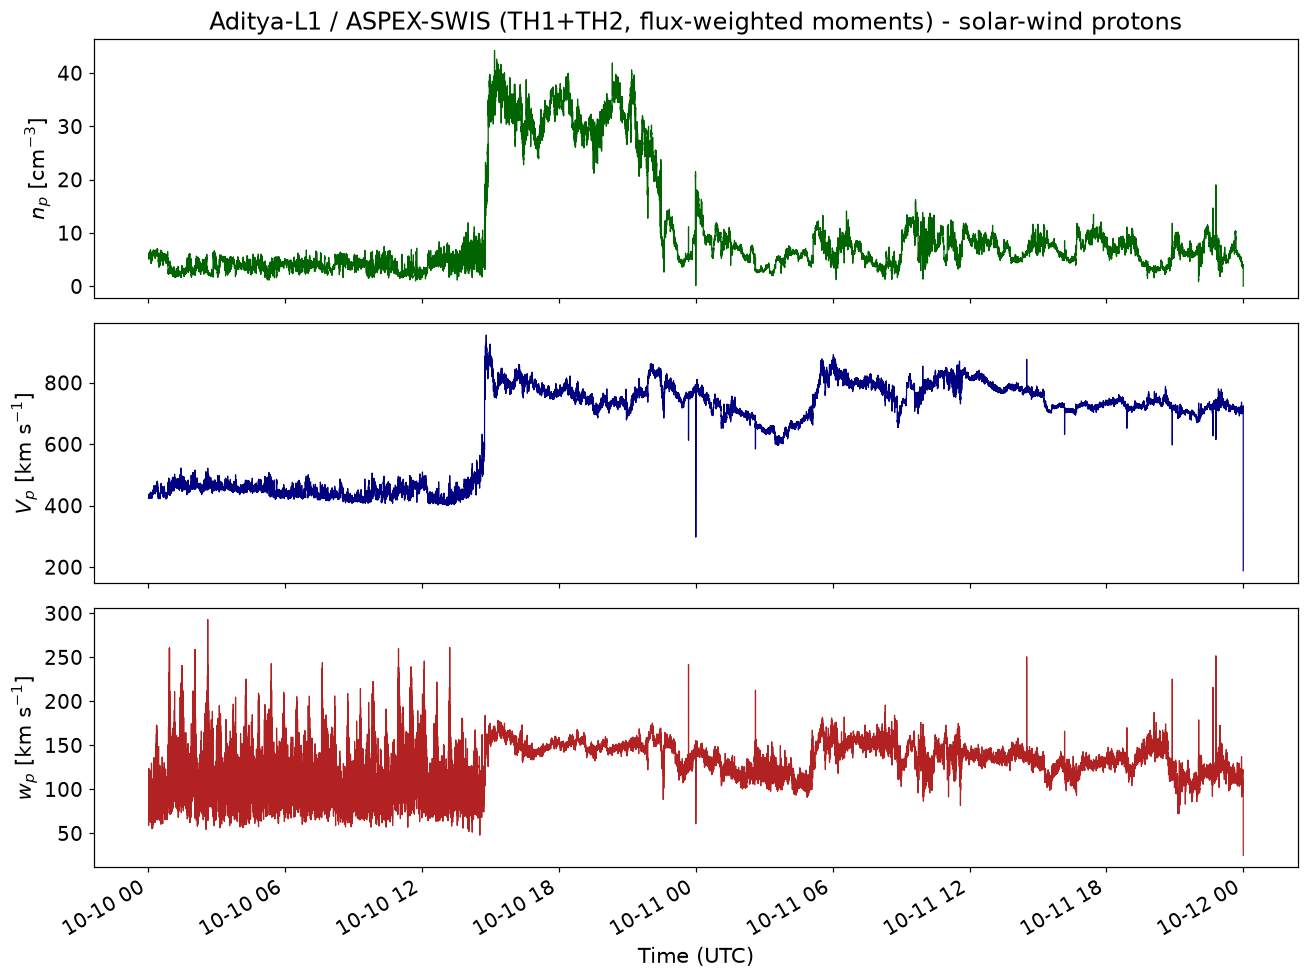

In [24]:
FS = 14

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

sw["proton_density"].plot(ax=ax[0], color="darkgreen", lw=0.8)
ax[0].set_ylabel(r"$n_p$ [cm$^{-3}$]", fontsize=FS)

sw["proton_bulk_speed"].plot(ax=ax[1], color="navy", lw=0.8)
ax[1].set_ylabel(r"$V_p$ [km s$^{-1}$]", fontsize=FS)

sw["proton_thermal"].plot(ax=ax[2], color="firebrick", lw=0.8)
ax[2].set_ylabel(r"$w_p$ [km s$^{-1}$]", fontsize=FS)

for a in ax:
    a.tick_params(axis="both", labelsize=FS - 1)

ax[2].set_xlabel("Time (UTC)", fontsize=FS)
ax[0].set_title("Aditya-L1 / ASPEX-SWIS (TH1+TH2, flux-weighted moments) - solar-wind protons", fontsize=FS + 2)
plt.tight_layout()
plt.show()


## 7. Derived plasma quantities

| Quantity | Formula | Why it matters |
|---|---|---|
| Dynamic pressure | $P_{dyn}=\rho V^2 = 1.6726\times10^{-6}\,(n_p+4n_\alpha)V^2$ nPa | compresses the magnetosphere |
| Proton temperature | $T_p = m_p w^2/2k_B$ | cold plasma is an ICME signature |
| Expected temperature | $T_{exp}=(0.031V-5.1)^2\times10^3$ K | empirical normal-solar-wind $T(V)$ (Lopez & Freeman 1986) |
| Plasma beta | $\beta = 2\mu_0 n k_B T/B^2$ | $\beta\ll1$ inside a magnetic cloud |
| Alfvén speed | $V_A = B/\sqrt{\mu_0 n m_p}$ | shock / Mach number |
| Alfvén Mach number | $M_A = V/V_A$ | shock strength |
| Merging electric field | $E_y = V_x B_z^{GSM}$ | solar-wind–magnetosphere coupling |
| Alpha-to-proton ratio | $n_\alpha/n_p$ | > 0.08 is a classic ICME/ejecta signature |

The velocity is measured by SWIS (5 s) and the field by MAG (10 s), so anything combining the
two first needs a **common time base**. We build one by averaging both onto a regular 1-minute
grid — `np.nan`-aware, so gaps stay gaps instead of being silently filled.

In [25]:
# MAG is 10 s, SWIS is 5 s -> average both to 1 minute so they can be combined.
# .mean() ignores NaN and gives NaN for an empty minute, so gaps stay gaps.
MAG_KEEP = ["Bx_gse", "By_gse", "Bz_gse",
            "Bx_gsm", "By_gsm", "Bz_gsm",
            "B_total", "clock", "cone",
            "x_gse", "y_gse", "z_gse"]

mag_1m  = df[MAG_KEEP].resample("1min").mean()
swis_1m = sw.resample("1min").mean()          # all SWIS columns

p = mag_1m.join(swis_1m, how="outer")         # one table, one time index

print(f"{len(p)} one-minute rows, {p.index[0]} -> {p.index[-1]}")
print("  minutes with field  :", int(p['B_total'].notna().sum()))
print("  minutes with plasma :", int(p['proton_bulk_speed'].notna().sum()))
print("  minutes with both   :", int((p['B_total'].notna() & p['proton_bulk_speed'].notna()).sum()))
print("\ncolumns:", list(p.columns))


2880 one-minute rows, 2024-10-10 00:00:00 -> 2024-10-11 23:59:00
  minutes with field  : 2880
  minutes with plasma : 2880
  minutes with both   : 2880

columns: ['Bx_gse', 'By_gse', 'Bz_gse', 'Bx_gsm', 'By_gsm', 'Bz_gsm', 'B_total', 'clock', 'cone', 'x_gse', 'y_gse', 'z_gse', 'proton_bulk_speed', 'proton_thermal', 'proton_density', 'proton_xvelocity', 'proton_yvelocity', 'proton_zvelocity', 'alpha_density']


In [26]:
n = p["proton_density"]        # cm^-3
V = p["proton_bulk_speed"]     # km/s
w = p["proton_thermal"]        # km/s
B = p["B_total"]               # nT

# proton temperature from the thermal speed:  T = m w^2 / 2k
p["Tp"] = MP * (w * 1e3)**2 / (2 * KB)                        # K

# dynamic pressure (alphas counted as 4 proton masses; missing alphas treated as 0)
p["Pdyn"] = 1.6726e-6 * (n + 4.0 * p["alpha_density"].fillna(0)) * V**2   # nPa

# plasma beta = thermal pressure / magnetic pressure
p["beta"] = 2 * MU0 * (n * 1e6) * KB * p["Tp"] / (B * 1e-9)**2

# Alfven speed and Mach number
p["Va"] = (B * 1e-9) / np.sqrt(MU0 * (n * 1e6) * MP) / 1e3    # km/s
p["Ma"] = V / p["Va"]

# merging electric field Ey = |Vx| * Bz  -> POSITIVE when the field is southward
p["Ey"] = -p["proton_xvelocity"].abs() * p["Bz_gsm"] * 1e-3    # mV/m

# alpha-to-proton ratio: not resolvable from this dataset (see note above)
p["alpha_ratio"] = p["alpha_density"] / n

DERIVED = ["Tp", "Pdyn", "beta", "Va", "Ma", "Ey", "alpha_ratio"]
print(p[DERIVED].describe().T[["count", "min", "mean", "max"]].round(3))


              count         min         mean          max
Tp           2880.0  312071.997  1013140.522  1903720.559
Pdyn         2880.0       0.647        9.002       51.676
beta         2880.0       0.056        1.889       16.240
Va           2880.0      37.303      135.149      499.287
Ma           2880.0       1.300        6.394       18.873
Ey           2880.0     -26.886        5.524       38.092
alpha_ratio     0.0         NaN          NaN          NaN


## 8. The combined MAG + SWIS overview

Seven panels on one shared time axis, built with plain `matplotlib`. Keep the label next to the data it describes — that habit is worth more than any plotting library.

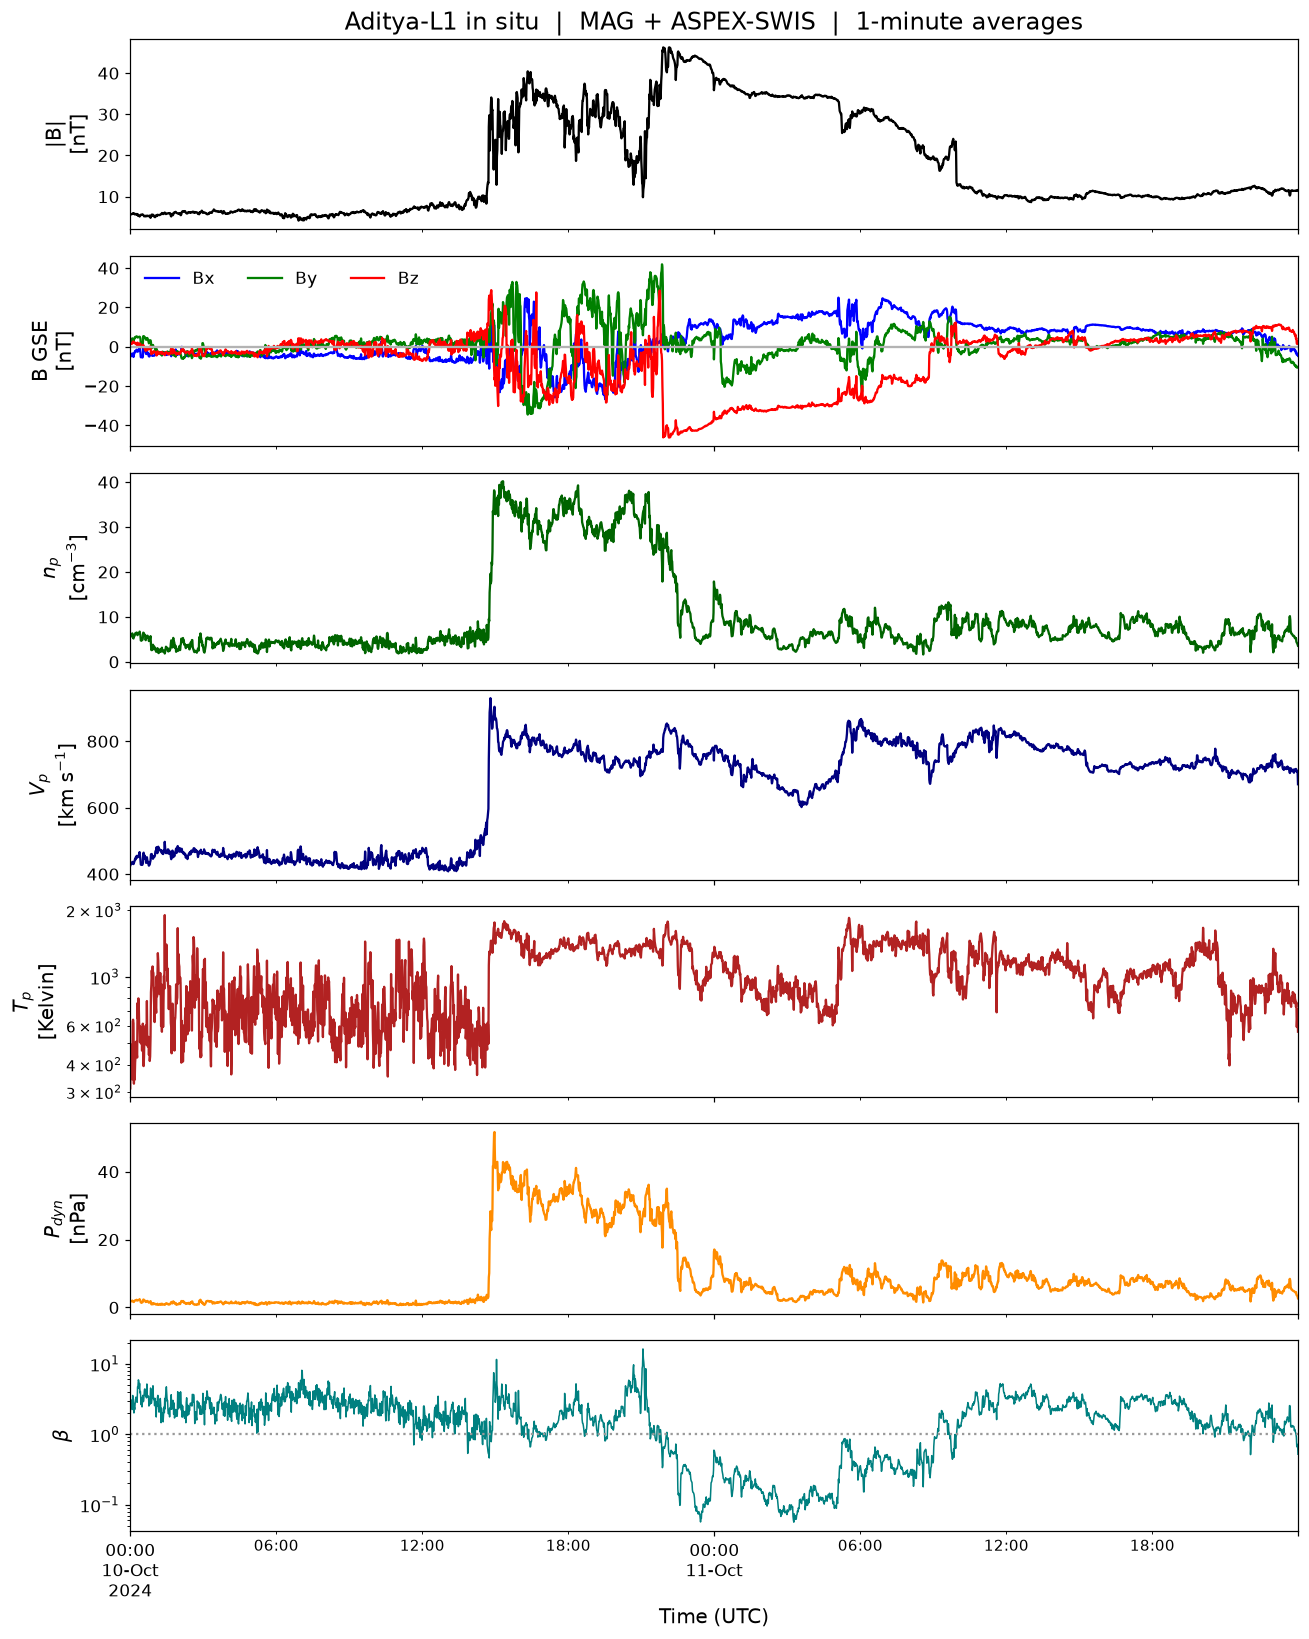

In [27]:
FS = 13

fig, ax = plt.subplots(7, 1, figsize=(12, 15), sharex=True)

# 1 - field magnitude
p["B_total"].plot(ax=ax[0], color="black", lw=1.5)
ax[0].set_ylabel("|B|\n[nT]", fontsize=FS)

# 2 - field components in GSE
p[["Bx_gse", "By_gse", "Bz_gse"]].plot(ax=ax[1], color=["blue", "green", "red"], lw=1.5)
ax[1].set_ylabel("B GSE\n[nT]", fontsize=FS)
ax[1].axhline(0, color="0.7", lw=1.5)
ax[1].legend(["Bx", "By", "Bz"], ncol=3, fontsize=FS - 2, frameon=False, loc="upper left")

# 3 - proton density
p["proton_density"].plot(ax=ax[2], color="darkgreen", lw=1.5)
ax[2].set_ylabel(r"$n_p$" "\n" r"[cm$^{-3}$]", fontsize=FS)

# 4 - bulk speed
p["proton_bulk_speed"].plot(ax=ax[3], color="navy", lw=1.5)
ax[3].set_ylabel(r"$V_p$" "\n" r"[km s$^{-1}$]", fontsize=FS)

# 5 - proton temperature (log, it spans two decades)
(p["Tp"] / 1e3).plot(ax=ax[4], color="firebrick", lw=1.5, logy=True)
ax[4].set_ylabel(r"$T_p$" "\n[Kelvin]", fontsize=FS)

# 6 - dynamic pressure
p["Pdyn"].plot(ax=ax[5], color="darkorange", lw=1.5)
ax[5].set_ylabel(r"$P_{dyn}$" "\n[nPa]", fontsize=FS)

# 7 - plasma beta (log; 0.1 marks the magnetic-cloud threshold)
p["beta"].plot(ax=ax[6], color="teal", lw=1.0, logy=True)
ax[6].axhline(1, color="0.6", lw=1.5, ls=":")
ax[6].set_ylabel(r"$\beta$", fontsize=FS)

for a in ax:
    a.tick_params(axis="both", labelsize=FS - 2)

ax[6].set_xlabel("Time (UTC)", fontsize=FS)
ax[0].set_title("Aditya-L1 in situ  |  MAG + ASPEX-SWIS  |  1-minute averages",
                fontsize=FS + 3)
plt.tight_layout()
plt.show()


### What the overview shows

Read the panels together, not one at a time — that is the whole skill:

* **Quiet solar wind** until ~15 UT on 10 October: $|B|\approx5$ nT, $V\approx400$ km s⁻¹,
  $n_p\approx4$ cm⁻³, $\beta\sim1$.
* **An abrupt, simultaneous jump** in $|B|$, $n_p$, $V$ and $T_p$ — the fingerprint of a
  **fast forward shock**. Everything jumps at once and in the same sense; that simultaneity is
  what distinguishes a shock from a mere discontinuity.
* **A turbulent, compressed, hot interval** behind it — the **sheath**: high $|B|$ but wildly
  fluctuating direction, high density, $\beta\gtrsim1$.
* **A smooth, strong-field, cold, low-$\beta$ interval** afterwards with the field direction
  rotating slowly and monotonically — the **magnetic cloud / ICME ejecta**.
* The speed stays high and decays slowly through 11 October — the expansion signature of the
  ejecta.

---

# Part A — Getting the solar wind from L1 to Earth

From here on we use only the one-minute table `p` built above, and plain pandas.

## 9. How long does the plasma take to reach the magnetosphere?

**Question A1 — Aditya-L1 sits 1.5 million km upstream. What does it measure *at* Earth?**

Nothing, directly. A structure seen at L1 at time $t$ reaches the magnetosphere later, after

$$\Delta t = \frac{X_{sc}-X_{BS}}{|V_x|}$$

where $X_{sc}$ is the measured spacecraft position (the `x_gse` column) and $X_{BS}$ is the
**bow shock nose**. The simplest picture — *flat-plane convection* — treats each structure as a
plane perpendicular to the Sun–Earth line carried anti-sunward at the measured speed.

Two standard refinements put $X_{BS}$ where it actually is:

**Magnetopause standoff — Shue et al. (1998).** The subsolar magnetopause moves with dynamic
pressure and with $B_z$:

$$r_0=\left(10.22+1.29\tanh\left[0.184(B_z+8.14)\right]\right)P_{dyn}^{-1/6.6}\ \ [R_E]$$

**Bow shock nose — Farris & Russell (1994).** The shock stands off the magnetopause by an amount
set by the magnetosonic Mach number:

$$X_{BS}=r_0\left[1+1.1\frac{(\gamma-1)M_{ms}^2+2}{(\gamma+1)(M_{ms}^2-1)}\right]$$

Both come out of Aditya-L1 data alone. We will use $r_0$ again in Part D, where it stops being a
step in a calculation and becomes a result in its own right.

In [28]:
# --- where the magnetopause and bow shock actually are, minute by minute ------
Cs  = np.sqrt(GAMMA * KB * p["Tp"] / MP) / 1e3      # sound speed [km/s]
Vms = np.sqrt(p["Va"]**2 + Cs**2)                    # magnetosonic speed [km/s]
p["Mms"] = p["proton_bulk_speed"] / Vms              # magnetosonic Mach number

# Shue et al. (1998) magnetopause standoff distance [Re]
p["r0"] = (10.22 + 1.29 * np.tanh(0.184 * (p["Bz_gsm"] + 8.14))) * p["Pdyn"]**(-1 / 6.6)

# Farris & Russell (1994): the bow shock stands off the magnetopause by an
# amount set by the magnetosonic Mach number. Near Mms = 1 the formula
# diverges (inside the magnetic cloud the flow is barely super-magnetosonic);
# that is clipped and replaced by the event median - a modelling choice, not a
# measurement, and reported as such.
ratio = ((GAMMA - 1) * p["Mms"]**2 + 2) / ((GAMMA + 1) * (p["Mms"]**2 - 1))
singular = np.abs(p["Mms"] - 1) < 0.05
n_clipped = int(singular.sum())
ratio = ratio.mask(singular)
ratio = ratio.fillna(ratio.median())
p["X_BS"] = p["r0"] * (1 + 1.1 * ratio)              # bow shock nose [Re]

print(f"magnetosonic Mach number: {p['Mms'].min():.2f} - {p['Mms'].max():.2f}")
print(f"samples clipped near the Mms=1 singularity: {n_clipped} "
      f"({100*n_clipped/p['Mms'].notna().sum():.1f}% of valid minutes)")
print(p[["r0", "X_BS"]].describe().T[["count", "min", "mean", "max"]].round(2))


magnetosonic Mach number: 1.27 - 6.32
samples clipped near the Mms=1 singularity: 0 (0.0% of valid minutes)
       count   min   mean    max
r0    2880.0  4.95   8.46  11.91
X_BS  2880.0  6.51  11.80  25.75


                  count   min   50%   max
delay_min        2880.0  28.6  36.4  63.9
delay_fixed_min  2880.0  28.0  35.9  63.8


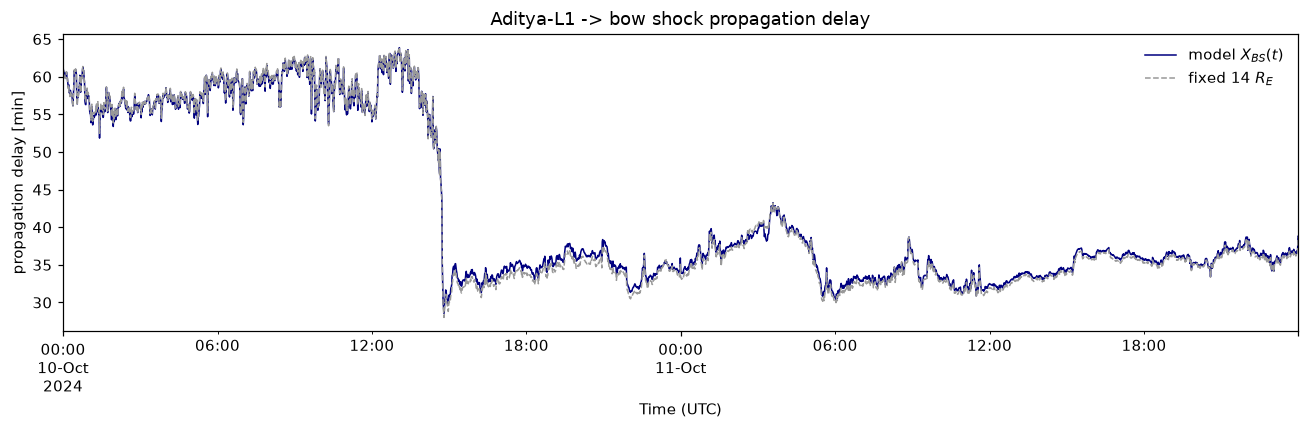

In [29]:
# --- flat-plane convection delay, minute by minute -----------------------------
Xsc_Re = p["x_gse"] / RE                 # spacecraft position [Re]
Vx = p["proton_xvelocity"].abs()         # [km/s], already anti-sunward by construction

delay_s = (Xsc_Re - p["X_BS"]) * RE / Vx   # Re*km/[km/s] -> s
p["delay_min"] = delay_s / 60.0

# naive comparison: same speed, but a fixed 14 Re bow-shock nose
delay_fixed_s = (Xsc_Re - 14.0) * RE / Vx
p["delay_fixed_min"] = delay_fixed_s / 60.0

print(p[["delay_min", "delay_fixed_min"]].describe().T[["count", "min", "50%", "max"]].round(1))

fig, ax = plt.subplots(figsize=(12, 4))
p["delay_min"].plot(ax=ax, color="navy", lw=1.0, label="model $X_{BS}(t)$")
p["delay_fixed_min"].plot(ax=ax, color="0.6", lw=1.0, ls="--", label="fixed 14 $R_E$")
ax.set_ylabel("propagation delay [min]")
ax.set_xlabel("Time (UTC)")
ax.set_title("Aditya-L1 -> bow shock propagation delay")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Summary statistics for delay_min, r0, and X_BS:
            count    min   mean    max
delay_min  2880.0  28.57  42.18  63.86
r0         2880.0   4.95   8.46  11.91
X_BS       2880.0   6.51  11.80  25.75

--------------------------------------------------



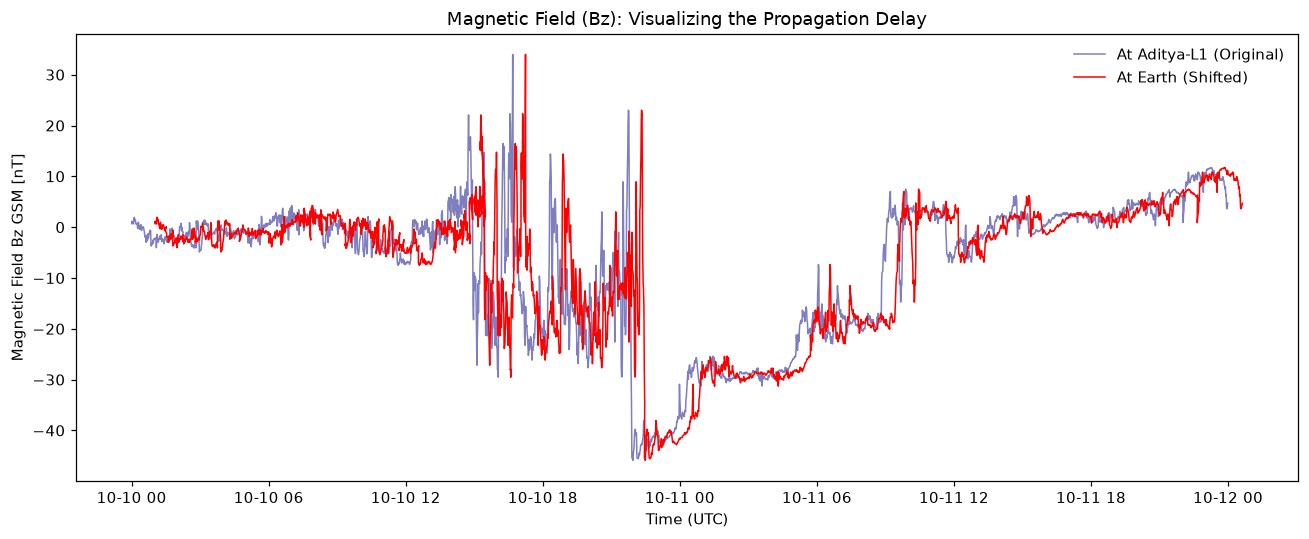

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# --- NEW: Print the values for delay_min, r0, and X_BS ---
print("Summary statistics for delay_min, r0, and X_BS:")
print(p[["delay_min", "r0", "X_BS"]].describe().T[["count", "min", "mean", "max"]].round(2))

# If you just want to see the first 5 actual rows of data instead of a summary, 
# you can uncomment the line below:
# print(p[["delay_min", "r0", "X_BS"]].head())
print("\n" + "-"*50 + "\n")

# --- Original Plotting Code ---
fig, ax = plt.subplots(figsize=(12, 5))

# Plot 1: Original using native matplotlib
ax.plot(p.index, p["Bz_gsm"], color="navy", lw=1.0, alpha=0.5, label="At Aditya-L1 (Original)")

# Calculate arrival time
arrival_time = p.index + pd.to_timedelta(p["delay_min"], unit="m")

# Plot 2: Shifted using native matplotlib
ax.plot(arrival_time, p["Bz_gsm"], color="red", lw=1.0, label="At Earth (Shifted)")

ax.set_ylabel("Magnetic Field Bz GSM [nT]")
ax.set_xlabel("Time (UTC)")
ax.set_title("Magnetic Field (Bz): Visualizing the Propagation Delay")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### What the delay plot shows

The delay collapses from roughly an hour in the slow pre-event wind to about half that behind the
shock, because the speed more than doubles. **A constant delay would therefore smear the event by
tens of minutes** — which is the whole justification for doing this properly.

Note also how little the *bow-shock model* matters compared with the speed: the difference between
the modelled nose and a fixed 14 $R_E$ is seconds, because the 245 $R_E$ of travel dominates. The
refinement is cheap and correct, but be honest in your report about which part of the calculation
is actually doing the work.

> **Caveat to state in your report.** Real solar-wind structures are *tilted*, not perpendicular
> to the Sun–Earth line. Our flat-plane delay is a good first approximation, not the truth.

## 10. Applying the shift

**Question A2 — what does "time-shifting" actually do to the table?**

It *relabels* each row: a sample measured at time $t$ at L1 is given the time $t+\Delta t$ at which
it reaches the bow shock. In pandas that is literally adding a `Timedelta` to the index.

Three consequences, all physical:

* the new times are **no longer evenly spaced**, so we re-bin onto a clean 1-minute grid;
* they can go **out of order** where the wind accelerates — fast plasma catching up with slow
  plasma — so we sort first;
* where arrival times bunch up, some minutes receive no sample at all. Those are holes created by
  the shift itself, not missing data, so we interpolate across them (interior only).

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Relabel each row: Add the propagation delay to the original L1 timestamp
shift_td = pd.to_timedelta(p["delay_min"], unit="min")
valid = shift_td.notna()

arrival_time = p.index + shift_td            
at_valid = arrival_time[valid]

# Print how much fast plasma caught up with slow plasma (reversed arrival order)
diffs = at_valid.diff().dropna()
reversed_frac = (diffs.dt.total_seconds() < 0).mean()
print(f"Minutes with reversed arrival order: {100*reversed_frac:.1f}%")

# 2. Assign the new arrival times and sort (handling fast plasma overtaking slow)
sh_raw = p.loc[valid].copy()
sh_raw.index = at_valid
# Drop any exact duplicates, then sort chronologically
sh_raw = sh_raw[~sh_raw.index.duplicated()].sort_index()   

# 3. Re-bin onto a clean 1-minute grid and interpolate over the holes 
# (limit_area="inside" prevents it from making up data past the edges)
sh = sh_raw.resample("1min").mean()
sh = sh.interpolate(method="time", limit_area="inside")

print(f"Shifted table ready: {sh.index[0]} -> {sh.index[-1]}, {len(sh)} rows")


Minutes with reversed arrival order: 5.0%
Shifted table ready: 2024-10-10 01:01:00 -> 2024-10-12 00:37:00, 2857 rows


In [19]:
# --- relabel each row with its arrival time at the bow shock -------------------
shift_td = pd.to_timedelta(p["delay_min"], unit="min")
valid = shift_td.notna()

arrival_time = p.index + shift_td            # NaT where delay is undefined
at_valid = arrival_time[valid]

# fraction of minutes whose arrival order is reversed by the shift (fast
# plasma catching up with slow plasma) - a physical effect, not a bug
diffs = at_valid.diff().dropna()
reversed_frac = (diffs.dt.total_seconds() < 0).mean()
print(f"minutes with reversed arrival order: {100*reversed_frac:.1f}%")

sh_raw = p.loc[valid].copy()
sh_raw.index = at_valid
sh_raw = sh_raw[~sh_raw.index.duplicated()].sort_index()   # sort: fast overtakes slow

# re-bin onto a clean 1-minute grid, then bridge only the interior holes the
# shift itself creates (no extrapolation past the edges)
sh = sh_raw.resample("1min").mean()
sh = sh.interpolate(method="time", limit_area="inside")

print(f"shifted table: {sh.index[0]} -> {sh.index[-1]}, {len(sh)} rows")


minutes with reversed arrival order: 5.0%
shifted table: 2024-10-10 01:01:00 -> 2024-10-12 00:37:00, 2857 rows


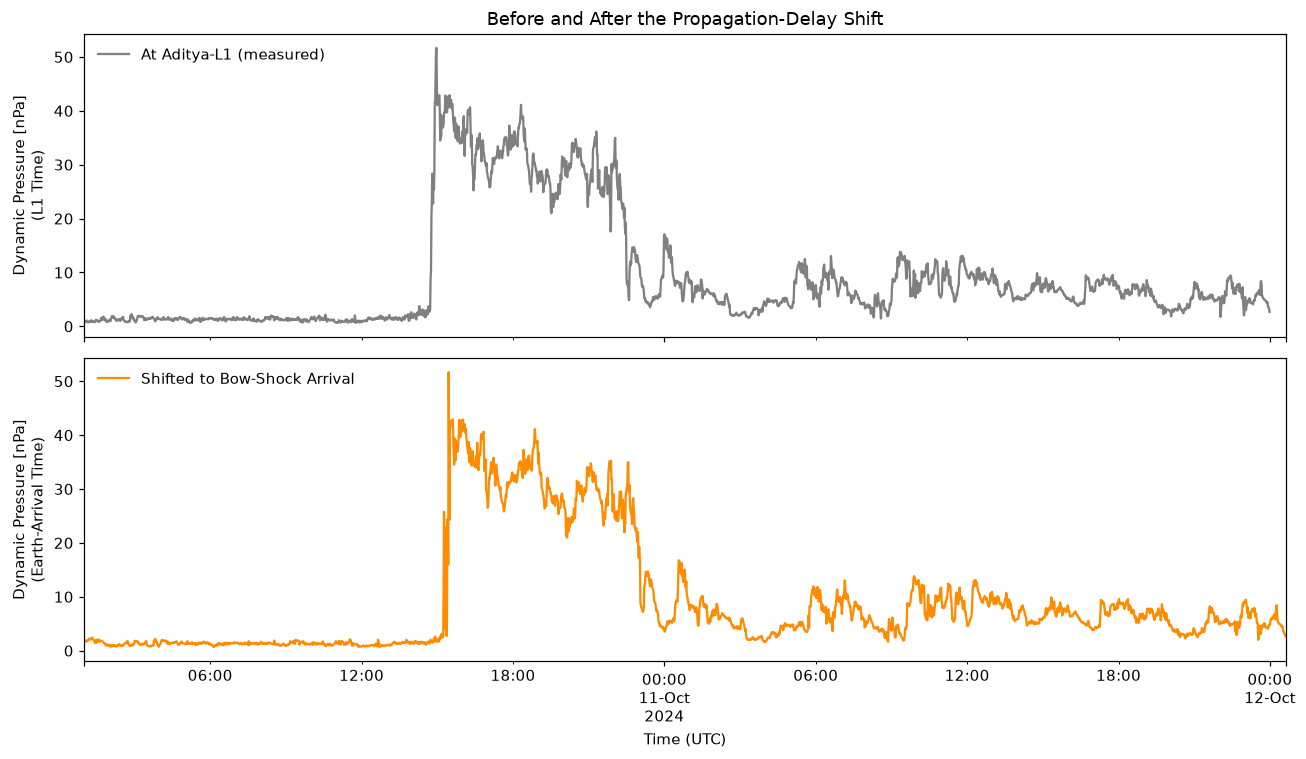

In [35]:
# Plot before (at L1) and after (at Earth) to verify the shift
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top panel: Unshifted data as measured at Aditya-L1
p["Pdyn"].plot(ax=ax[0], color="0.5", lw=1.5, label="At Aditya-L1 (measured)")
ax[0].set_ylabel("Dynamic Pressure [nPa]\n(L1 Time)")
ax[0].legend(frameon=False, loc="upper left")
ax[0].set_title("Before and After the Propagation-Delay Shift")

# Bottom panel: Shifted data using our new `sh` table
sh["Pdyn"].plot(ax=ax[1], color="darkorange", lw=1.5, label="Shifted to Bow-Shock Arrival")
ax[1].set_ylabel("Dynamic Pressure [nPa]\n(Earth-Arrival Time)")
ax[1].legend(frameon=False, loc="upper left")

ax[1].set_xlabel("Time (UTC)")
plt.tight_layout()
plt.show()


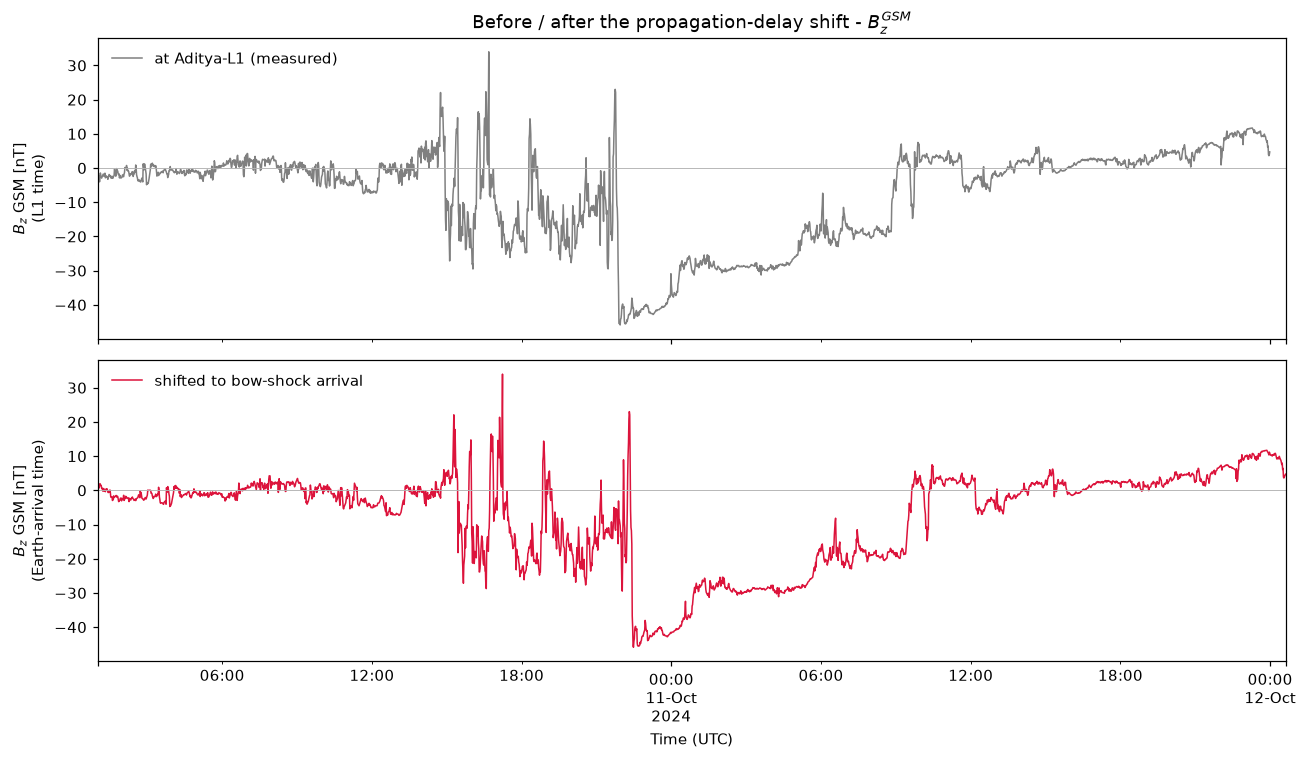

In [36]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

p["Bz_gsm"].plot(ax=ax[0], color="0.5", lw=1.0, label="at Aditya-L1 (measured)")
ax[0].axhline(0, color="0.7", lw=0.6)
ax[0].set_ylabel("$B_z$ GSM [nT]\n(L1 time)")
ax[0].legend(frameon=False, loc="upper left")

sh["Bz_gsm"].plot(ax=ax[1], color="crimson", lw=1.0, label="shifted to bow-shock arrival")
ax[1].axhline(0, color="0.7", lw=0.6)
ax[1].set_ylabel("$B_z$ GSM [nT]\n(Earth-arrival time)")
ax[1].legend(frameon=False, loc="upper left")

ax[1].set_xlabel("Time (UTC)")
ax[0].set_title(r"Before / after the propagation-delay shift - $B_z^{GSM}$")
plt.tight_layout()
plt.show()


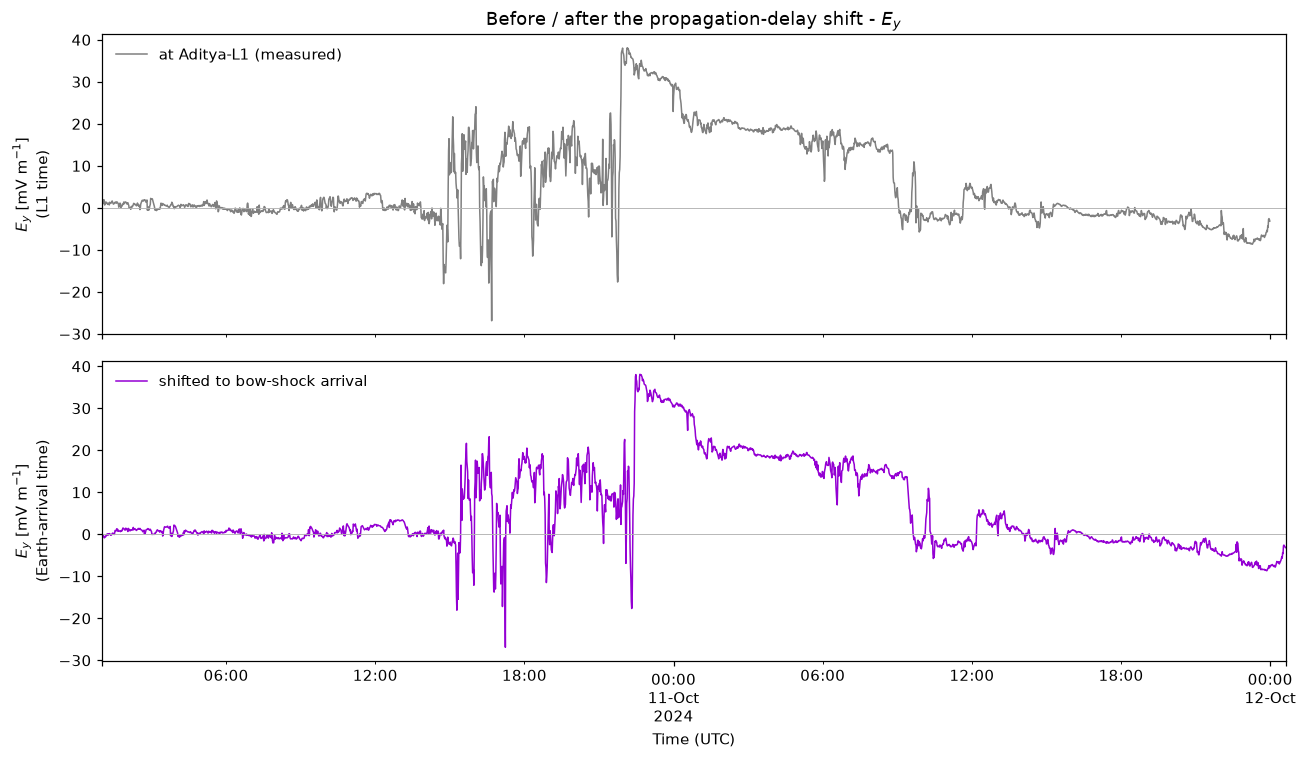

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

p["Ey"].plot(ax=ax[0], color="0.5", lw=1.0, label="at Aditya-L1 (measured)")
ax[0].axhline(0, color="0.7", lw=0.6)
ax[0].set_ylabel("$E_y$ [mV m$^{-1}$]\n(L1 time)")
ax[0].legend(frameon=False, loc="upper left")

sh["Ey"].plot(ax=ax[1], color="darkviolet", lw=1.0, label="shifted to bow-shock arrival")
ax[1].axhline(0, color="0.7", lw=0.6)
ax[1].set_ylabel("$E_y$ [mV m$^{-1}$]\n(Earth-arrival time)")
ax[1].legend(frameon=False, loc="upper left")

ax[1].set_xlabel("Time (UTC)")
ax[0].set_title("Before / after the propagation-delay shift - $E_y$")
plt.tight_layout()
plt.show()


The two curves have the same *shape* and are displaced by the delay — that is the check that the
shift did what you think it did. Measure the displacement of the shock front by eye and compare it
with the median delay printed in Section 9.

## 11. The storm onset, from Aditya-L1 alone

**Question A3 — when did the storm begin? Answer without looking at any ground data.**

The shock arrives, the dynamic pressure jumps, and the magnetosphere is compressed. That pressure
jump is visible in the Aditya-L1 data hours before anyone on the ground sees anything, so we use
**Aditya-L1 to define the onset time** and keep the ground data for marking, not for deciding.

In [38]:
# --- storm onset from Aditya-L1 alone: the sharpest rise in dynamic pressure --
dPdyn = p["Pdyn"].diff()
ONSET_L1 = dPdyn.idxmax()                       # time the shock crosses Aditya-L1
onset_delay_min = p.loc[ONSET_L1, "delay_min"]
ONSET_EARTH = ONSET_L1 + pd.Timedelta(minutes=onset_delay_min)

print(f"shock seen at Aditya-L1    : {ONSET_L1}")
print(f"predicted arrival at Earth : {ONSET_EARTH}  (delay {onset_delay_min:.1f} min)")

# quiet reference levels before the onset - for marking/comparison only, never
# used to initialise the Part C model (which must start neutral)
quiet_mask = p.index < ONSET_L1
QUIET_PDYN = p.loc[quiet_mask, "Pdyn"].median()
QUIET_EY   = p.loc[quiet_mask, "Ey"].median()
print(f"quiet-time reference: Pdyn = {QUIET_PDYN:.2f} nPa, Ey = {QUIET_EY:.2f} mV/m")


shock seen at Aditya-L1    : 2024-10-10 14:54:00
predicted arrival at Earth : 2024-10-10 15:24:53.243983094  (delay 30.9 min)
quiet-time reference: Pdyn = 1.33 nPa, Ey = 0.37 mV/m


---

# Part B — Scoring the prediction against the ground

## 12. SYM-H and AE from OMNI — the ground truth, and nothing more

* **SYM-H** — the 1-minute symmetric-H index: the globally averaged, low-latitude magnetic
  depression caused by the **ring current**. Essentially Dst at 1-minute resolution. Storms are
  classified by its minimum: moderate (−50 nT), intense (−100 nT), super (−250 nT).
* **AE** — the auroral electrojet index: substorm and high-latitude current activity.

**These two series are the answer sheet.** They are never an input to anything we compute; they
exist so that the prediction in Section 13 can be marked.

The cell below tries two sources, so it works online or offline:

1. **a direct download from NASA/SPDF** — the OMNI "HRO2" 1-minute CDF for the month, read with the
   same `cdflib` we already use for SWIS;
2. **a local OMNIWeb ASCII file** in `Data/omni/` — this takes priority, so a file you downloaded
   by hand always wins over the network.

To make the local file: go to <https://omniweb.gsfc.nasa.gov/form/omni_min.html>, select
**2024-10-09 to 2024-10-13**, tick **SYM/H index** and **AE index**, choose "list data", and save
the result as `Data/omni/omni_symh_ae.txt`. The columns are then
`year  day-of-year  hour  minute  SYM-H  AE`.

In [40]:
import os
import pandas as pd
import urllib.request
import cdflib

DATA_DIR = "data"
OMNI_DIR = os.path.join(DATA_DIR, "omni")
os.makedirs(OMNI_DIR, exist_ok=True)
local_txt = os.path.join(OMNI_DIR, "omni_symh_ae.txt")

if os.path.exists(local_txt):
    print("Using local OMNIWeb file:", local_txt)
    cols = ["year", "doy", "hour", "minute", "SYM_H", "AE"]
    raw = pd.read_csv(local_txt, delim_whitespace=True, names=cols, comment="#")
    t = (pd.to_datetime(raw["year"].astype(str), format="%Y")
         + pd.to_timedelta(raw["doy"] - 1, unit="D")
         + pd.to_timedelta(raw["hour"], unit="h")
         + pd.to_timedelta(raw["minute"], unit="min"))
    omni = pd.DataFrame({"SYM_H": raw["SYM_H"], "AE": raw["AE"]}, index=t)
else:
    print("No local OMNI text file found - downloading the HRO2 1-minute CDF from SPDF directly...")
    url = ("https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro2_1min/2024/"
           "omni_hro2_1min_20241001_v01.cdf")
    cdf_path = os.path.join(OMNI_DIR, "omni_hro2_1min_20241001_v01.cdf")
    
    # Download the CDF if we don't have it yet
    if not os.path.exists(cdf_path):
        urllib.request.urlretrieve(url, cdf_path)
        
    oc = cdflib.CDF(cdf_path)
    ot = cdflib.cdfepoch.unixtime(oc.varget("Epoch"))
    omni = pd.DataFrame({"SYM_H": oc.varget("SYM_H"),
                         "AE": oc.varget("AE_INDEX")},
                        index=pd.to_datetime(ot, unit="s"))

# 4. Clean up the data (mask out OMNI fill values, which are usually 99999 or 9999)
omni = omni.mask(omni.abs() >= 9999)            

# Trim to match exactly the timeframe of your Aditya-L1 measurements ('p' dataframe)
omni = omni.loc[p.index[0]:p.index[-1]]          

# Ensure a clean 1-minute grid
omni = omni.resample("1min").mean()

print(f"\nOMNI Data Ready: {omni.index[0]} -> {omni.index[-1]}, {len(omni)} rows")
print(omni.describe().round(1))


No local OMNI text file found - downloading the HRO2 1-minute CDF from SPDF directly...

OMNI Data Ready: 2024-10-10 00:00:00 -> 2024-10-11 23:59:00, 2880 rows
        SYM_H      AE
count  2880.0  2880.0
mean   -132.0   641.1
std     106.3   591.4
min    -390.0    42.0
25%    -231.0   201.0
50%    -111.0   448.0
75%     -22.0   926.2
max      78.0  4274.0


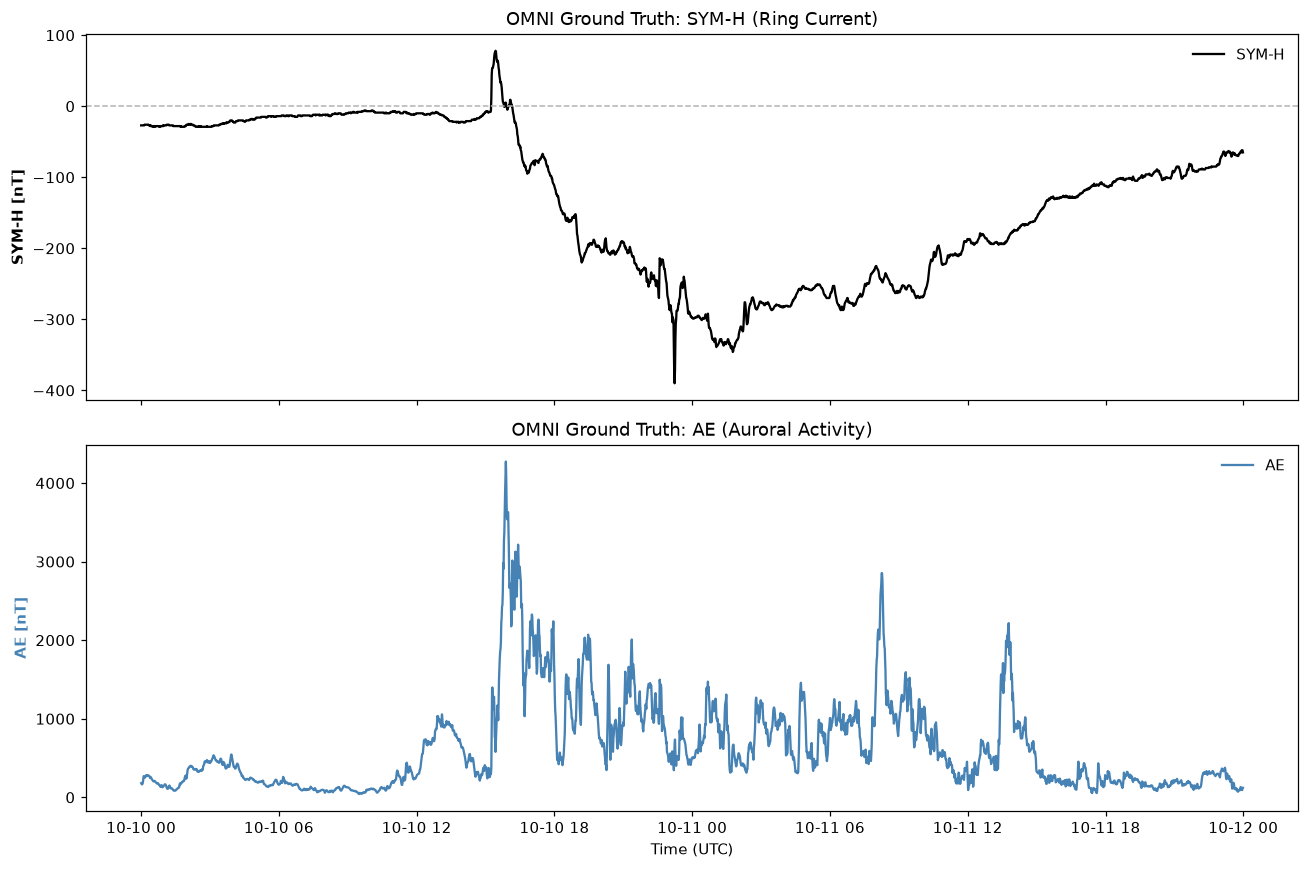

In [43]:
import matplotlib.pyplot as plt

# Create 2 rows (panels) and 1 column, sharing the same X (time) axis
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Top Panel: SYM-H ---
ax[0].plot(omni.index, omni["SYM_H"], color="black", lw=1.5, label="SYM-H")
ax[0].set_ylabel("SYM-H [nT]", weight="bold")
ax[0].set_title("OMNI Ground Truth: SYM-H (Ring Current)")
ax[0].axhline(0, color="0.7", lw=1.0, ls="--") # Add a zero line
ax[0].legend(frameon=False)

# --- Bottom Panel: AE ---
ax[1].plot(omni.index, omni["AE"], color="steelblue", lw=1.5, label="AE")
ax[1].set_ylabel("AE [nT]", color="steelblue", weight="bold")
ax[1].set_title("OMNI Ground Truth: AE (Auroral Activity)")
ax[1].set_xlabel("Time (UTC)")
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 13. The driver and the response on one axis

Everything above the dividing line is the solar wind **as it arrives at the magnetosphere**
(Aditya-L1, time-shifted); below it is the ground response. Because both share a time axis, cause
and effect can be read off directly.

In [46]:
# import matplotlib.pyplot as plt
# import pandas as pd

# # First, find the storm onset to draw a line across all plots
# dPdyn = p["Pdyn"].diff()
# ONSET_L1 = dPdyn.idxmax()                       
# onset_delay_min = p.loc[ONSET_L1, "delay_min"]
# ONSET_EARTH = ONSET_L1 + pd.Timedelta(minutes=onset_delay_min)

# # Create a 4-panel figure sharing the X axis
# # gridspec_kw makes the bottom panel slightly taller
# fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True,
#                        gridspec_kw={"height_ratios": [1, 1, 1, 1.3]})

# # --- Panel 1: Magnetic Field Bz (Shifted Driver) ---
# ax[0].plot(sh.index, sh["Bz_gsm"], color="red", lw=1.0)
# ax[0].axhline(0, color="0.7", lw=0.6)
# ax[0].set_ylabel("$B_z$ GSM\n[nT]")

# # --- Panel 2: Electric Field Ey (Shifted Driver) ---
# ax[1].plot(sh.index, sh["Ey"], color="darkviolet", lw=1.0)
# ax[1].axhline(0, color="0.7", lw=0.6)
# ax[1].set_ylabel("$E_y$\n[mV m$^{-1}$]")

# # --- Panel 3: Dynamic Pressure (Shifted Driver) ---
# ax[2].plot(sh.index, sh["Pdyn"], color="darkorange", lw=1.0)
# ax[2].set_ylabel("$P_{dyn}$\n[nPa]")

# # --- Panel 4: Ground Response (SYM-H and AE) ---
# ax[3].plot(omni.index, omni["SYM_H"], color="black", lw=1.2, label="SYM-H")
# ax[3].set_ylabel("SYM-H [nT]")

# ax3b = ax[3].twinx()
# ax3b.plot(omni.index, omni["AE"], color="steelblue", lw=0.8, alpha=0.6, label="AE")
# ax3b.set_ylabel("AE [nT]", color="steelblue")

# # Add the vertical dashed line for the predicted storm onset across all panels
# for a in ax:
#     a.axvline(ONSET_EARTH, color="green", ls="--", lw=1.2)
#     a.tick_params(axis="both", labelsize=10)

# ax[0].set_title("Shifted Aditya-L1 driver (top three) vs ground response (bottom)\n"
#                 "Dashed green line: predicted shock arrival at Earth", fontsize=13)
# ax[-1].set_xlabel("Time (UTC)")

# plt.tight_layout()
# plt.show()

# # Print out the minimum SYM-H and maximum AE
# print(f"Minimum SYM-H: {omni['SYM_H'].min():.1f} nT at {omni['SYM_H'].idxmin()}")
# print(f"Maximum AE   : {omni['AE'].max():.0f} nT at {omni['AE'].idxmax()}")


### What to read off this figure

* the **pressure jump** at the blue line — an onset time Aditya-L1 gave you, with no ground data;
* the long interval of **$B_z<0$ / $E_y>0$** that follows, and the steep SYM-H decrease under it;
* the **lag** between the deepest $B_z$ and the deepest SYM-H — the ring current integrates the
  input rather than following it, so tens of minutes are expected;
* where SYM-H turns around, and whether $B_z$ turned northward first.

Write those four readings down with times. The next section does the same thing with physics.

---

# Part C — Predicting SYM-H from Aditya-L1 alone

## 14. The ring current as a leaky bucket

**Question C — given only what Aditya-L1 measured, could you have predicted the storm?**

This is the real test of the whole chain — data reduction, quality control, the time shift and the
physics — because **nothing about the ground data enters the calculation**. The observed SYM-H is
used once, at the end, to mark the result.

The **Burton et al. (1975)** equation with **O'Brien & McPherron (2000)** coefficients treats the
ring current as a bucket filled by the merging electric field and leaking with a field-dependent
time constant:

$$\frac{dDst^*}{dt}=Q(E_y)-\frac{Dst^*}{\tau},\qquad
  Q=-4.4\,(E_y-0.49)\ \ {\rm for}\ E_y>0.49,\ \ {\rm else}\ 0$$

$$\tau=2.40\exp\!\left(\frac{9.74}{4.69+E_y}\right)\ {\rm hours},\qquad
  Dst = Dst^* + b\sqrt{P_{dyn}} - c,\quad b=7.26,\ c=11$$

The $\sqrt{P_{dyn}}$ term is the **magnetopause-current** contribution — compression rather than
ring current, and the part that produces the sudden impulse. Both inputs, $E_y$ and $P_{dyn}$, come
from the **shifted** Aditya-L1 table `sh`.

Correlation            : 0.93
RMS error              : 40.7 nT
Observed minimum SYM-H : -390.0 nT at 2024-10-10 23:14:00
Predicted minimum SYM-H: -309.3 nT at 2024-10-11 03:18:00
Timing error at minimum: +244.0 min


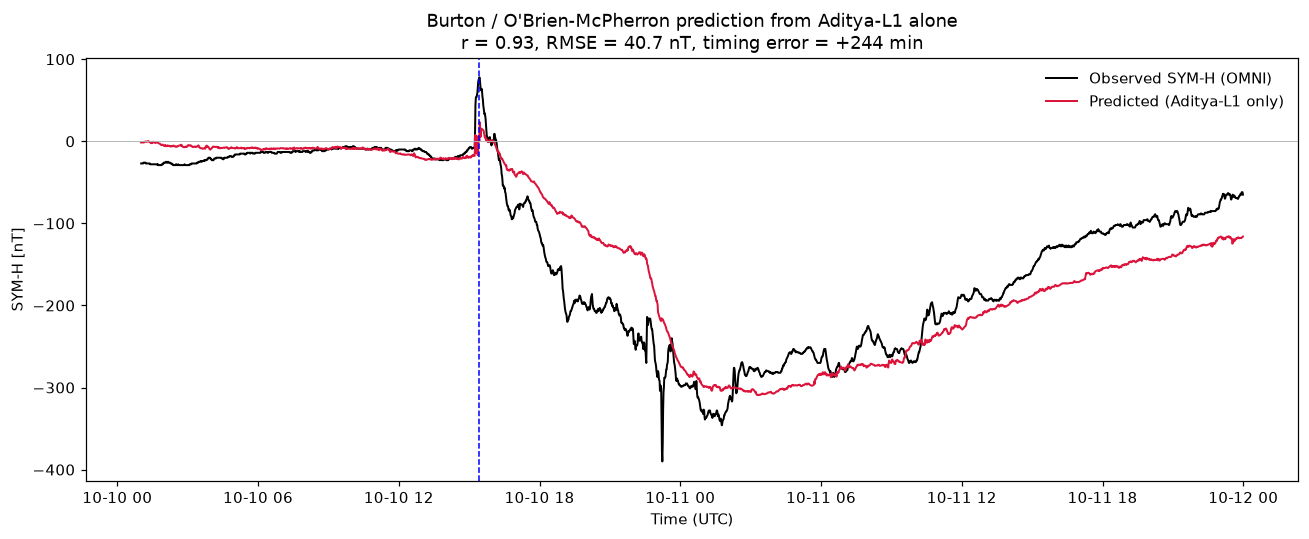

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 14. The ring current as a leaky bucket, driven ONLY by shifted Aditya-L1 data ---
def burton_obrien(Ey, dt_hr=1 / 60.0):
    """Integrate dDst*/dt = Q(Ey) - Dst*/tau(Ey), starting neutral (Dst*[0] = 0)."""
    Ey = Ey.to_numpy()
    Dst_star = np.zeros(len(Ey))
    
    for i in range(1, len(Ey)):
        e = Ey[i - 1]
        if not np.isfinite(e):
            Dst_star[i] = Dst_star[i - 1]
            continue
            
        # The injection term (Q)
        Qinj = -4.4 * (e - 0.49) if e > 0.49 else 0.0     # nT/hour
        
        # The decay time (tau)
        e_tau = max(e, 0.0)
        tau = 2.40 * np.exp(9.74 / (4.69 + e_tau))         # hours
        
        # Leaky bucket equation
        dDdt = Qinj - Dst_star[i - 1] / tau                # nT/hour
        Dst_star[i] = Dst_star[i - 1] + dDdt * dt_hr
        
    return Dst_star

# Fill any small holes in the data before running the simulation
Ey_s = sh["Ey"].interpolate(limit_area="inside")
Pdyn_s = sh["Pdyn"].interpolate(limit_area="inside")

# Run the simulation
Dst_star = burton_obrien(Ey_s)

# Add the magnetopause-current contribution (the square root of Pdyn)
SYMH_pred = pd.Series(Dst_star, index=sh.index) + 7.26 * np.sqrt(Pdyn_s.clip(lower=0)) - 11.0

# Combine predicted vs observed into one table to score it
cmp = pd.DataFrame({"pred": SYMH_pred, "obs": omni["SYM_H"]}).dropna()

# Calculate the scores
corr = cmp["pred"].corr(cmp["obs"])
rmse = np.sqrt(((cmp["pred"] - cmp["obs"])**2).mean())
t_obs_min, t_pred_min = cmp["obs"].idxmin(), cmp["pred"].idxmin()
timing_err_min = (t_pred_min - t_obs_min).total_seconds() / 60.0

print(f"Correlation            : {corr:.2f}")
print(f"RMS error              : {rmse:.1f} nT")
print(f"Observed minimum SYM-H : {cmp['obs'].min():.1f} nT at {t_obs_min}")
print(f"Predicted minimum SYM-H: {cmp['pred'].min():.1f} nT at {t_pred_min}")
print(f"Timing error at minimum: {timing_err_min:+.1f} min")

# --- Plot the final Prediction vs Reality ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cmp.index, cmp["obs"], color="black", lw=1.3, label="Observed SYM-H (OMNI)")
ax.plot(cmp.index, cmp["pred"], color="crimson", lw=1.3, label="Predicted (Aditya-L1 only)")

ax.axhline(0, color="0.7", lw=0.6)
ax.axvline(ONSET_EARTH, color="blue", ls="--", lw=1.0) # Changed to blue!
ax.legend(frameon=False)
ax.set_ylabel("SYM-H [nT]")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"Burton / O'Brien-McPherron prediction from Aditya-L1 alone\n"
             f"r = {corr:.2f}, RMSE = {rmse:.1f} nT, timing error = {timing_err_min:+.0f} min")
plt.tight_layout()
plt.show()


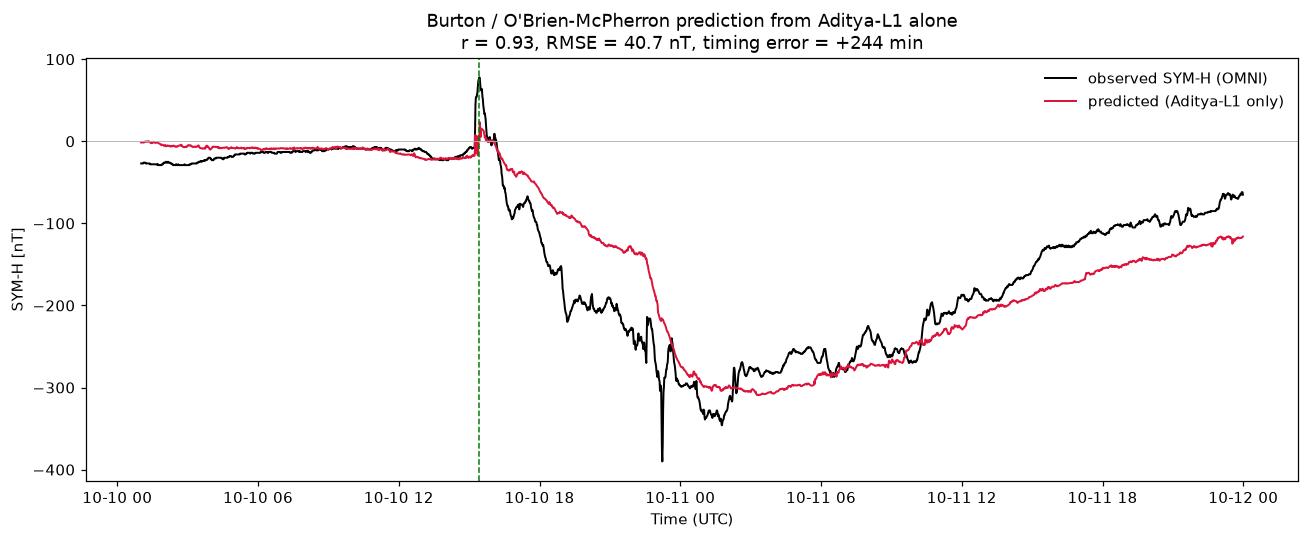

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cmp.index, cmp["obs"], color="black", lw=1.3, label="observed SYM-H (OMNI)")
ax.plot(cmp.index, cmp["pred"], color="crimson", lw=1.3, label="predicted (Aditya-L1 only)")
ax.axhline(0, color="0.7", lw=0.6)
ax.axvline(ONSET_EARTH, color="green", ls="--", lw=1.0)
ax.legend(frameon=False)
ax.set_ylabel("SYM-H [nT]")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"Burton / O'Brien-McPherron prediction from Aditya-L1 alone\n"
             f"r = {corr:.2f}, RMSE = {rmse:.1f} nT, timing error = {timing_err_min:+.0f} min")
plt.tight_layout()
plt.show()


### How to read the mismatch

A model driven by a single upstream spacecraft will not match perfectly, and **the ways it fails
are the result** — not the failure:

* **too shallow** → the merging electric field was underestimated: gaps in the SWIS velocity, or
  the coupling is stronger than the linear $E_y$ term assumes;
* **too deep** → ring-current saturation, which a linear injection term cannot capture;
* **right depth, wrong time** → the propagation delay is off, or the magnetosphere's own response
  time is not zero;
* **recovery too fast or too slow** → $\tau(E_y)$ was fitted to a statistical ensemble of storms
  and need not fit this one.

Quote the RMS error, the correlation and the timing error at the minimum, and say which of the four
descriptions fits your figure.